In [1]:
# # Netflix Movies and TV Shows EDA

# ## Why I chose this dataset
#  I chose the Netflix Movies and TV Shows dataset because it is easy to understand and has both movies and series, so I can compare different patterns in the data.

# ## What I want to find
# In this notebook, I want to explore these questions:

# 1. Does Netflix add mostly recent content or older content?
# 2. Are movies and TV shows given different ratings?
# 3. Which countries seem to contribute newer content?
# 4. Which genres are more common in movies and which are more common in TV shows?
# 5. Are some months more active than others for adding content to Netflix? 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [8]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [11]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [12]:
# for our EDA questions


In [13]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

In [14]:
df["content_age_at_addition"] = df["year_added"] - df["release_year"]

In [15]:
df[["title", "type", "release_year", "year_added", "content_age_at_addition"]].head(10)

,title,type,release_year,year_added,content_age_at_addition
0,Dick Johnson Is Dead,Movie,2020,2021.0,1.0
1,Blood & Water,TV Show,2021,2021.0,0.0
2,Ganglands,TV Show,2021,2021.0,0.0
3,Jailbirds New Orleans,TV Show,2021,2021.0,0.0
4,Kota Factory,TV Show,2021,2021.0,0.0
5,Midnight Mass,TV Show,2021,2021.0,0.0
6,My Little Pony: A New Generation,Movie,2021,2021.0,0.0
7,Sankofa,Movie,1993,2021.0,28.0
8,The Great British Baking Show,TV Show,2021,2021.0,0.0
9,The Starling,Movie,2021,2021.0,0.0


In [16]:
df.isnull().sum().sort_values(ascending=False)

date_added                 98
year_added                 98
month_added                98
content_age_at_addition    98
duration                    3
show_id                     0
type                        0
title                       0
director                    0
cast                        0
country                     0
release_year                0
rating                      0
listed_in                   0
description                 0
dtype: int64

In [17]:
df["month_added"]

0       September
1       September
2       September
3       September
4       September
          ...    
8802     November
8803         July
8804     November
8805      January
8806        March
Name: month_added, Length: 8807, dtype: object

In [18]:
df["date_added"].isna().sum()

np.int64(98)

In [19]:
df["year_gap_at_addition"].value_counts().sort_index().head(15)

KeyError: 'year_gap_at_addition'

In [20]:
df["year_gap_at_addition"].value_counts().sort_index().head(15)

KeyError: 'year_gap_at_addition'

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

netflix_df = pd.read_csv("netflix_titles.csv")

netflix_df["director"] = netflix_df["director"].fillna("Unknown")
netflix_df["cast"] = netflix_df["cast"].fillna("Unknown")
netflix_df["country"] = netflix_df["country"].fillna("Unknown")
netflix_df["rating"] = netflix_df["rating"].fillna(netflix_df["rating"].mode()[0])

netflix_df["date_added"] = pd.to_datetime(netflix_df["date_added"], errors="coerce")
netflix_df["year_added"] = netflix_df["date_added"].dt.year
netflix_df["month_added"] = netflix_df["date_added"].dt.month_name()
netflix_df["year_gap_at_addition"] = netflix_df["year_added"] - netflix_df["release_year"]

print("Column created?", "year_gap_at_addition" in netflix_df.columns)
print(netflix_df[["title", "release_year", "year_added", "year_gap_at_addition"]].head())
print(netflix_df["year_gap_at_addition"].value_counts().sort_index().head(15))

Column created? True
                   title  release_year  year_added  year_gap_at_addition
0   Dick Johnson Is Dead          2020      2021.0                   1.0
1          Blood & Water          2021      2021.0                   0.0
2              Ganglands          2021      2021.0                   0.0
3  Jailbirds New Orleans          2021      2021.0                   0.0
4           Kota Factory          2021      2021.0                   0.0
year_gap_at_addition
-3.0        1
-2.0        1
-1.0       12
 0.0     3222
 1.0     1559
 2.0      707
 3.0      484
 4.0      358
 5.0      260
 6.0      247
 7.0      183
 8.0      183
 9.0      160
 10.0     134
 11.0     135
Name: count, dtype: int64


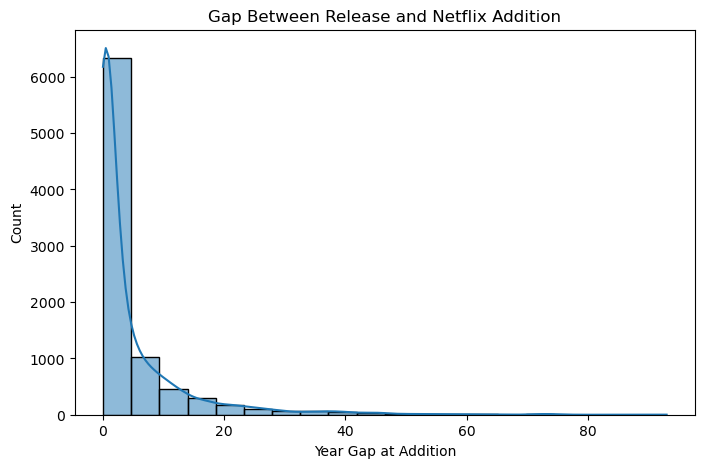

In [22]:

fresh_df = netflix_df[netflix_df["year_gap_at_addition"].notna()]
fresh_df = fresh_df[fresh_df["year_gap_at_addition"] >= 0]

plt.figure(figsize=(8,5))
sns.histplot(fresh_df["year_gap_at_addition"], bins=20, kde=True)
plt.title("Gap Between Release and Netflix Addition")
plt.xlabel("Year Gap at Addition")
plt.ylabel("Count")
plt.show()

In [23]:
netflix_df["year_gap_at_addition"].describe()

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: year_gap_at_addition, dtype: float64

In [24]:
### Observation

# Most titles seem to be added within a few years of release.
# This suggests that Netflix contains a large amount of relatively recent content.
# At the same time, the right side of the chart shows that some older titles are also added much later.

In [26]:
fresh_df["freshness_group"] = pd.cut(
    fresh_df["year_gap_at_addition"],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=["Same year", "1-2 years", "3-5 years", "6-10 years", "More than 10 years"]
)

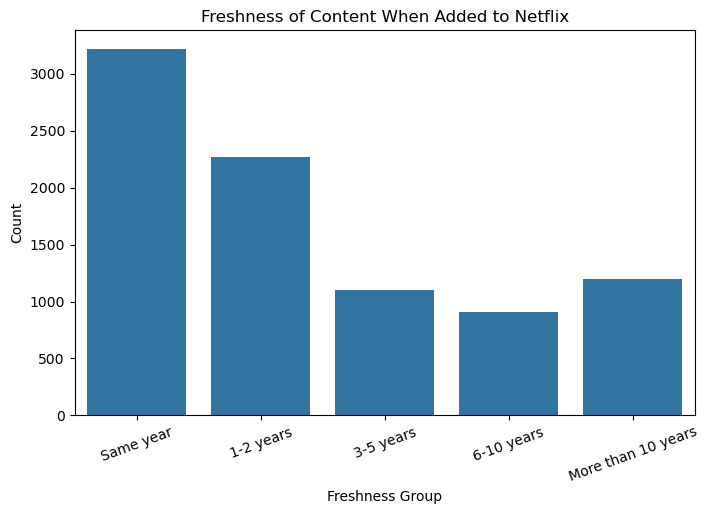

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="freshness_group",
    data=fresh_df,
    order=["Same year", "1-2 years", "3-5 years", "6-10 years", "More than 10 years"]
)
plt.title("Freshness of Content When Added to Netflix")
plt.xlabel("Freshness Group")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [28]:
#  Netflix mostly adds fresh releases, but it also sprinkles in older titles to keep the library diverse.



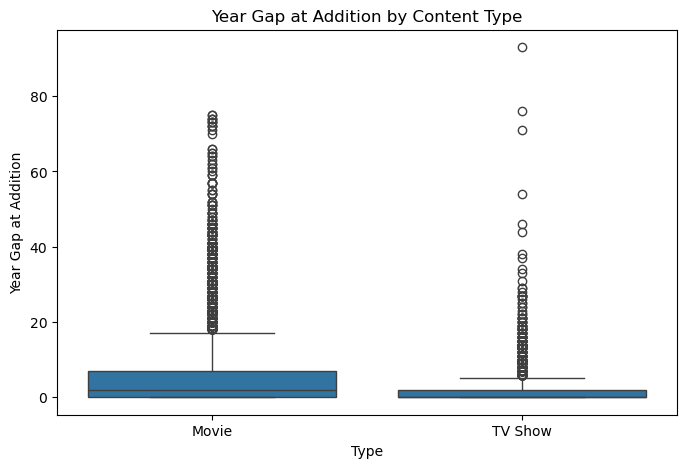

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x="type", y="year_gap_at_addition", data=fresh_df)
plt.title("Year Gap at Addition by Content Type")
plt.xlabel("Type")
plt.ylabel("Year Gap at Addition")
plt.show()

In [30]:
# movie areolder than tv shows when added

In [31]:
fresh_df.groupby("type")["year_gap_at_addition"].mean()

type
Movie      5.729972
TV Show    2.241231
Name: year_gap_at_addition, dtype: float64

In [32]:
fresh_df.groupby("type")["year_gap_at_addition"].median()

type
Movie      2.0
TV Show    0.0
Name: year_gap_at_addition, dtype: float64

In [33]:
# Do Movies and TV Shows follow different rating patterns

In [34]:
netflix_df["rating"].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

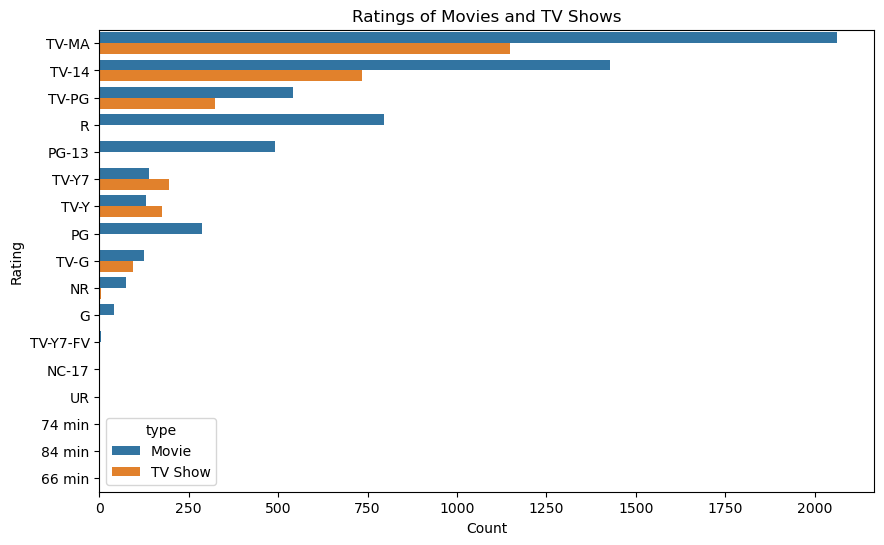

In [35]:
plt.figure(figsize=(10,6))
sns.countplot(data=netflix_df, y="rating", hue="type", order=netflix_df["rating"].value_counts().index)
plt.title("Ratings of Movies and TV Shows")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

In [36]:
#  many type of rating systems are used and TV MA TV 14 are most used for bothh movie and tv series

In [37]:
rating_type_table = pd.crosstab(netflix_df["rating"], netflix_df["type"])
rating_type_table


type,Movie,TV Show
rating,,
66 min,1,0
74 min,1,0
84 min,1,0
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2


In [38]:
rating_type_percent = pd.crosstab(netflix_df["rating"], netflix_df["type"], normalize="index") * 100
rating_type_percent

type,Movie,TV Show
rating,,
66 min,100.000000,0.000000
74 min,100.000000,0.000000
84 min,100.000000,0.000000
G,100.000000,0.000000
NC-17,100.000000,0.000000
NR,93.750000,6.250000
PG,100.000000,0.000000
PG-13,100.000000,0.000000
R,99.749687,0.250313


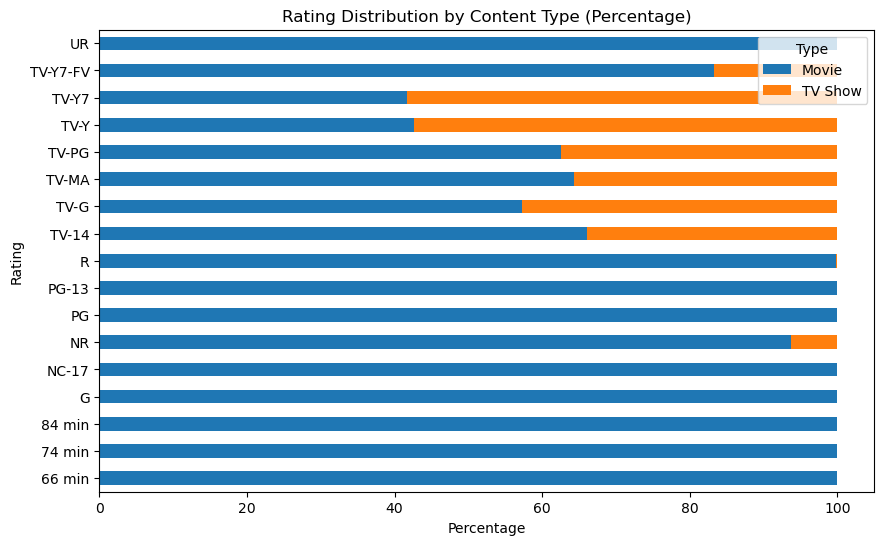

In [39]:
rating_type_percent.plot(kind="barh", stacked=True, figsize=(10,6))
plt.title("Rating Distribution by Content Type (Percentage)")
plt.xlabel("Percentage")
plt.ylabel("Rating")
plt.legend(title="Type")
plt.show()

In [40]:
#  tv shows and movies are rated differently but both have some share all type of ratings

In [41]:
# 3 Q: Which countries contribute fresher content, and 
#  which contribute older content?Which countries contribute fresher content, and which contribute older content?

In [42]:
country_df = fresh_df.copy()
country_df = country_df[country_df["country"] != "Unknown"]

In [43]:
country_df["country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("country")


In [44]:
country_df["country"].value_counts().head(10)

country
United States     3631
India             1045
United Kingdom     784
Canada             429
France             388
Japan              313
Spain              228
South Korea        226
Germany            225
Mexico             168
Name: count, dtype: int64

In [45]:
top_countries = country_df["country"].value_counts().head(10).index
top_country_df = country_df[country_df["country"].isin(top_countries)]

In [46]:
country_gap_mean = top_country_df.groupby("country")["year_gap_at_addition"].mean().sort_values()
country_gap_mean

country
Spain             1.710526
South Korea       1.787611
Mexico            2.910714
Canada            3.766900
United Kingdom    4.947704
Japan             4.968051
France            5.012887
Germany           5.320000
United States     5.714128
India             6.691866
Name: year_gap_at_addition, dtype: float64

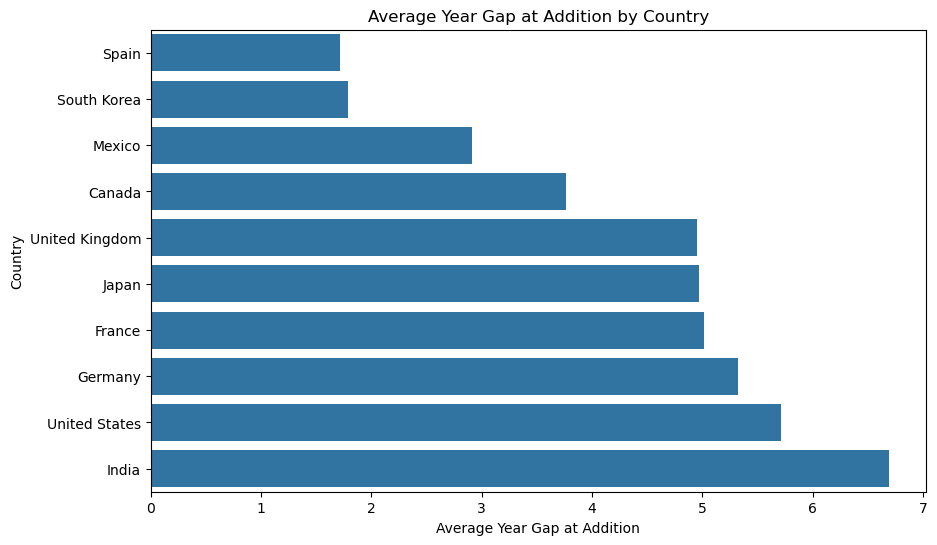

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_gap_mean.values, y=country_gap_mean.index)
plt.title("Average Year Gap at Addition by Country")
plt.xlabel("Average Year Gap at Addition")
plt.ylabel("Country")
plt.show()

In [48]:
### Observation

# Some countries appear to have relatively fresh content with lower average delay before Netflix addition.
# Other countries show a higher average gap, which suggests more dependence on older content.


In [49]:
#  median plot as mean cant be accurate measure in thse cases

In [51]:
country_gap_median = top_country_df.groupby("country")["year_gap_at_addition"].median().sort_values()
country_gap_median

country
Mexico            0.0
South Korea       1.0
Spain             1.0
United States     1.0
Canada            2.0
France            2.0
Germany           2.0
Japan             2.0
United Kingdom    2.0
India             3.0
Name: year_gap_at_addition, dtype: float64

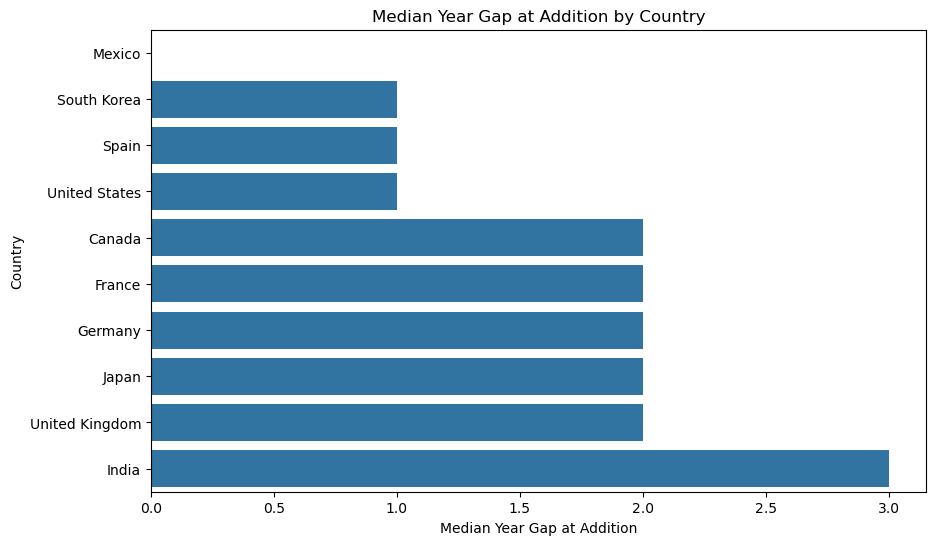

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_gap_median.values, y=country_gap_median.index)
plt.title("Median Year Gap at Addition by Country")
plt.xlabel("Median Year Gap at Addition")
plt.ylabel("Country")
plt.show()

In [53]:
country_summary = top_country_df.groupby("country").agg(
    total_titles=("title", "count"),
    avg_gap=("year_gap_at_addition", "mean"),
    median_gap=("year_gap_at_addition", "median")
).sort_values("total_titles", ascending=False)

country_summary

,total_titles,avg_gap,median_gap
country,,,
United States,3631,5.714128,1.0
India,1045,6.691866,3.0
United Kingdom,784,4.947704,2.0
Canada,429,3.766900,2.0
France,388,5.012887,2.0
Japan,313,4.968051,2.0
Spain,228,1.710526,1.0
South Korea,226,1.787611,1.0
Germany,225,5.320000,2.0


In [55]:
#  still India tops in avg gap and median gap , which shows netflix adds more old movies , in India
#  which shows different contributes in different ways , in total titles, ang gap aand freshness

In [56]:
# Q4: Which genres are more movie-dominant and which are more TV-show-dominant?

In [57]:
genre_df = netflix_df.copy()

In [58]:
genre_df["genre"] = genre_df["listed_in"].str.split(", ")

In [59]:
genre_df = genre_df.explode("genre")

In [60]:
genre_df["genre"].value_counts().head(10)

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [61]:
top_genres = genre_df["genre"].value_counts().head(10).index
top_genre_df = genre_df[genre_df["genre"].isin(top_genres)]

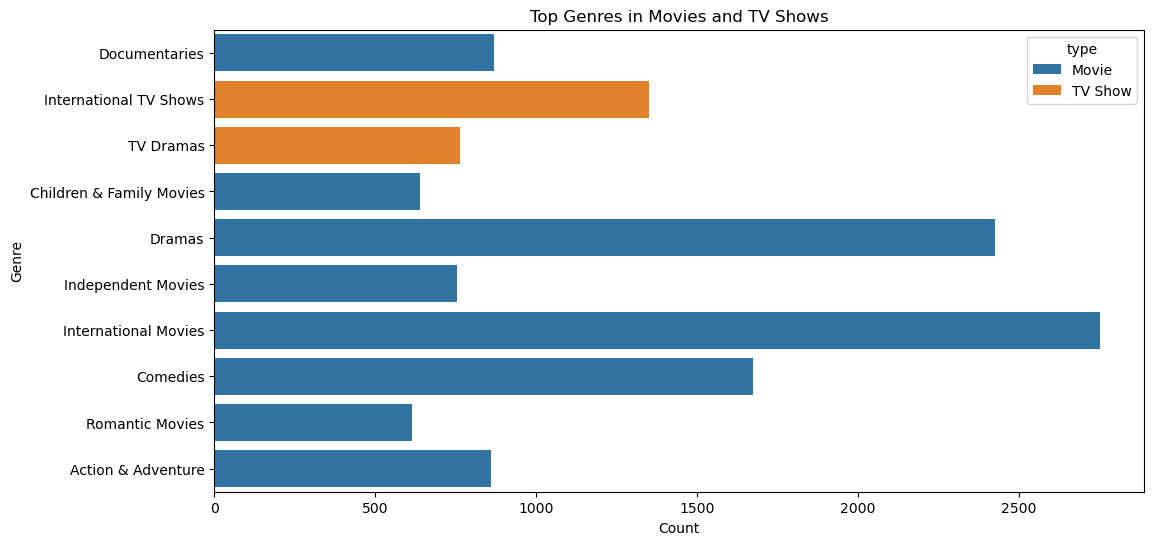

In [62]:
plt.figure(figsize=(12,6))
sns.countplot(data=top_genre_df, y="genre", hue="type")
plt.title("Top Genres in Movies and TV Shows")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()